In [2]:
from libraries import *
from parameters import *
from util import *

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp


def _sum_and_sumsq(X) -> tuple[np.ndarray, np.ndarray]:
    """Column-wise sum and sum of squares for dense or sparse matrices."""
    if sp.issparse(X):
        s = np.asarray(X.sum(axis=0)).ravel().astype(np.float64, copy=False)
        ss = np.asarray(X.multiply(X).sum(axis=0)).ravel().astype(np.float64, copy=False)
    else:
        Xd = np.asarray(X, dtype=np.float64)
        s = Xd.sum(axis=0)
        ss = (Xd * Xd).sum(axis=0)
    return s, ss


def _mean_and_var_from_sum(s: np.ndarray, ss: np.ndarray, n: int) -> tuple[np.ndarray, np.ndarray]:
    """From sum and sumsq compute mean and unbiased variance (ddof=1)."""
    mean = s / n
    if n < 2:
        var = np.zeros_like(mean, dtype=np.float64)
        return mean, var

    ex2 = ss / n
    var_pop = np.maximum(ex2 - mean * mean, 0.0)
    var = var_pop * (n / (n - 1))
    return mean, var


def compute_log_mean_diff_and_se_huge(
    adata,
    *,
    group_key: str = "target_gene",
    control_label: str = "non-targeting",
    layer: str | None = None,
    min_cells: int = 20,
    chunk_perts: int = 100,
    out_path: str | Path | None = None,
) -> pd.DataFrame:
    """
    Efficiently compute mean difference (mean_pert - mean_ctrl) and its SE in log-expression space
    for each perturbation vs controls, and ALSO include the per-group means.

    Output columns:
      perturbation, gene, mean_pert, mean_ctrl, mean_diff, se, n_pert, n_ctrl
    """
    X = adata.layers[layer] if layer is not None else adata.X
    if sp.issparse(X):
        X = X.tocsr()

    groups = adata.obs[group_key].astype("string").to_numpy()
    genes = adata.var_names.to_numpy()

    ctrl_mask = groups == control_label
    n_ctrl = int(ctrl_mask.sum())
    if n_ctrl < 2:
        raise ValueError(f"Need >=2 control cells, found {n_ctrl}.")

    # ---- control stats once ----
    s_c, ss_c = _sum_and_sumsq(X[ctrl_mask])
    mean_c, var_c = _mean_and_var_from_sum(s_c, ss_c, n_ctrl)

    # ---- perturbations to process ----
    pert_counts = pd.Series(groups).value_counts()
    perts = [p for p in np.unique(groups) if p != control_label]
    perts = [p for p in perts if int(pert_counts.get(p, 0)) >= min_cells]

    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        chunk_dir = out_path.with_suffix("")  # e.g. results.parquet -> results/
        chunk_dir.mkdir(parents=True, exist_ok=True)
        chunk_files: list[Path] = []
    else:
        out_chunks: list[pd.DataFrame] = []

    # ---- process in chunks ----
    for start in range(0, len(perts), chunk_perts):
        batch = perts[start : start + chunk_perts]

        rows = []
        for pert in batch:
            pert_mask = groups == pert
            n_p = int(pert_mask.sum())
            if n_p < 2:
                continue

            s_p, ss_p = _sum_and_sumsq(X[pert_mask])
            mean_p, var_p = _mean_and_var_from_sum(s_p, ss_p, n_p)

            mean_diff = mean_p - mean_c
            se = np.sqrt(var_p / n_p + var_c / n_ctrl)

            # NOTE: mean_ctrl is identical for all perts; we still include it as requested.
            df = pd.DataFrame(
                {
                    "perturbation": pert,
                    "gene": genes,
                    "mean_pert": mean_p,
                    "mean_ctrl": mean_c,
                    "mean_diff": mean_diff,
                    "se": se,
                    "n_pert": n_p,
                    "n_ctrl": n_ctrl,
                }
            )
            rows.append(df)

        chunk_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

        if out_path is not None:
            f = chunk_dir / f"chunk_{start:06d}.parquet"
            chunk_df.to_parquet(f, index=False)
            chunk_files.append(f)
            print(f"[{start//chunk_perts+1}] wrote {f} ({len(chunk_df):,} rows)")
        else:
            out_chunks.append(chunk_df)
            print(f"[{start//chunk_perts+1}] computed chunk ({len(chunk_df):,} rows)")

    if out_path is not None:
        out = (
            pd.concat((pd.read_parquet(f) for f in chunk_files), ignore_index=True)
            if chunk_files
            else pd.DataFrame()
        )
        out.to_csv(out_path, index=False)
        print(f"[done] wrote consolidated parquet: {out_path}")
        return out

    return pd.concat(out_chunks, ignore_index=True) if out_chunks else pd.DataFrame()


In [3]:
cond="AR-A014418"
a=sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1_Basak/"+cond+"/"+cond+".h5ad")

In [4]:
a

AnnData object with n_obs × n_vars = 2194499 × 18154
    obs: 'sample', 'experiment', 'lane_id', 'bc_idx', 'assignment_geomux', 'umis_geomux', 'moi_geomux', 'n_reads_gex', 'n_reads_crispr', 'n_umis_gex', 'n_umis_crispr', 'cell', 'moi_mixture', 'assignment_mixture', 'umis_mixture', 'assignment', 'moi', 'umis', 'batch', 'target_gene', 'target_gene_name', 'target_guide_umi', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'KnockDownEfficiency', 'KnockDownGeneFC'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'

In [26]:
df = compute_log_mean_diff_and_se_huge(
    a,
    group_key="target_gene",
    control_label="non-targeting",
    layer=None,  # adata.X already log
    min_cells=20,
    chunk_perts=100,
    out_path="logFC_meanDiff_se.parquet",
)

[1] wrote logFC_meanDiff_se/chunk_000000.parquet (1,815,400 rows)
[2] wrote logFC_meanDiff_se/chunk_000100.parquet (1,815,400 rows)
[3] wrote logFC_meanDiff_se/chunk_000200.parquet (1,815,400 rows)
[4] wrote logFC_meanDiff_se/chunk_000300.parquet (1,815,400 rows)
[5] wrote logFC_meanDiff_se/chunk_000400.parquet (1,815,400 rows)
[6] wrote logFC_meanDiff_se/chunk_000500.parquet (1,815,400 rows)
[7] wrote logFC_meanDiff_se/chunk_000600.parquet (1,815,400 rows)
[8] wrote logFC_meanDiff_se/chunk_000700.parquet (1,815,400 rows)
[9] wrote logFC_meanDiff_se/chunk_000800.parquet (1,815,400 rows)
[10] wrote logFC_meanDiff_se/chunk_000900.parquet (1,815,400 rows)
[11] wrote logFC_meanDiff_se/chunk_001000.parquet (1,815,400 rows)
[12] wrote logFC_meanDiff_se/chunk_001100.parquet (1,815,400 rows)
[13] wrote logFC_meanDiff_se/chunk_001200.parquet (1,815,400 rows)
[14] wrote logFC_meanDiff_se/chunk_001300.parquet (1,815,400 rows)
[15] wrote logFC_meanDiff_se/chunk_001400.parquet (1,815,400 rows)
[16]

In [30]:
import pandas as pd

df = pd.read_parquet("logFC_meanDiff_se.parquet")


In [31]:
df

,perturbation,gene,mean_pert,mean_ctrl,mean_diff,se,n_pert,n_ctrl
0,A1BG,TSPAN6,2.035162,2.043624,-0.008462,0.008689,2540,274774
1,A1BG,TNMD,0.026880,0.023858,0.003022,0.002666,2540,274774
2,A1BG,DPM1,1.813661,1.810603,0.003058,0.008492,2540,274774
3,A1BG,SCYL3,0.168065,0.171647,-0.003583,0.006079,2540,274774
4,A1BG,C1orf112,1.021843,1.005742,0.016101,0.010182,2540,274774
...,...,...,...,...,...,...,...,...
37397235,ZZZ3,PPP5D1P,0.000000,0.008356,-0.008356,0.000136,39,274774
37397236,ZZZ3,SOD2,0.884728,1.061725,-0.176998,0.087591,39,274774
37397237,ZZZ3,gfp,2.868830,3.000771,-0.131940,0.082775,39,274774
37397238,ZZZ3,dCas9,1.186689,1.055429,0.131261,0.105033,39,274774


In [33]:
deRes = pd.read_csv("./AR-A014418/AR-A014418_res.csv",index_col=0)

In [32]:
df.columns=["target", "feature", "mean_pert","mean_ctrl","mean_diff", "se", "n_pert", "n_ctrl"]

In [34]:
deRes["meanDiff"]=deRes["target_mean"] - deRes["reference_mean"]

In [35]:
merged = pd.merge(
    df,
    deRes,
    on=["target", "feature"],   # merge keys
    how="inner"            # inner, left, right, outer
)


In [36]:
m=merged.iloc[0:100000,:]

In [41]:
tmp=a[a.obs["target_gene"]=="A1BG",]

In [48]:
tmp.X.shape[0]

2540

In [49]:
means = np.sum(tmp.X,axis=0) / tmp.X.shape[0]

In [50]:
means

matrix([[2.0351622 , 0.02687996, 1.8136609 , ..., 3.006302  , 1.0527161 ,
         1.0872498 ]], shape=(1, 18154), dtype=float32)

In [51]:
tmp.var_names

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'ZNF781', 'ENSG00000291096', 'TRIM16L', 'CASTOR3P', 'FCGR1BP',
       'PPP5D1P', 'SOD2', 'gfp', 'dCas9', 'bfp'],
      dtype='object', name='feature', length=18154)

In [53]:
df = pd.DataFrame({
    "meanExp": means,
    "GeneName": tmp.var_names.to_numpy()
})

ValueError: Per-column arrays must each be 1-dimensional

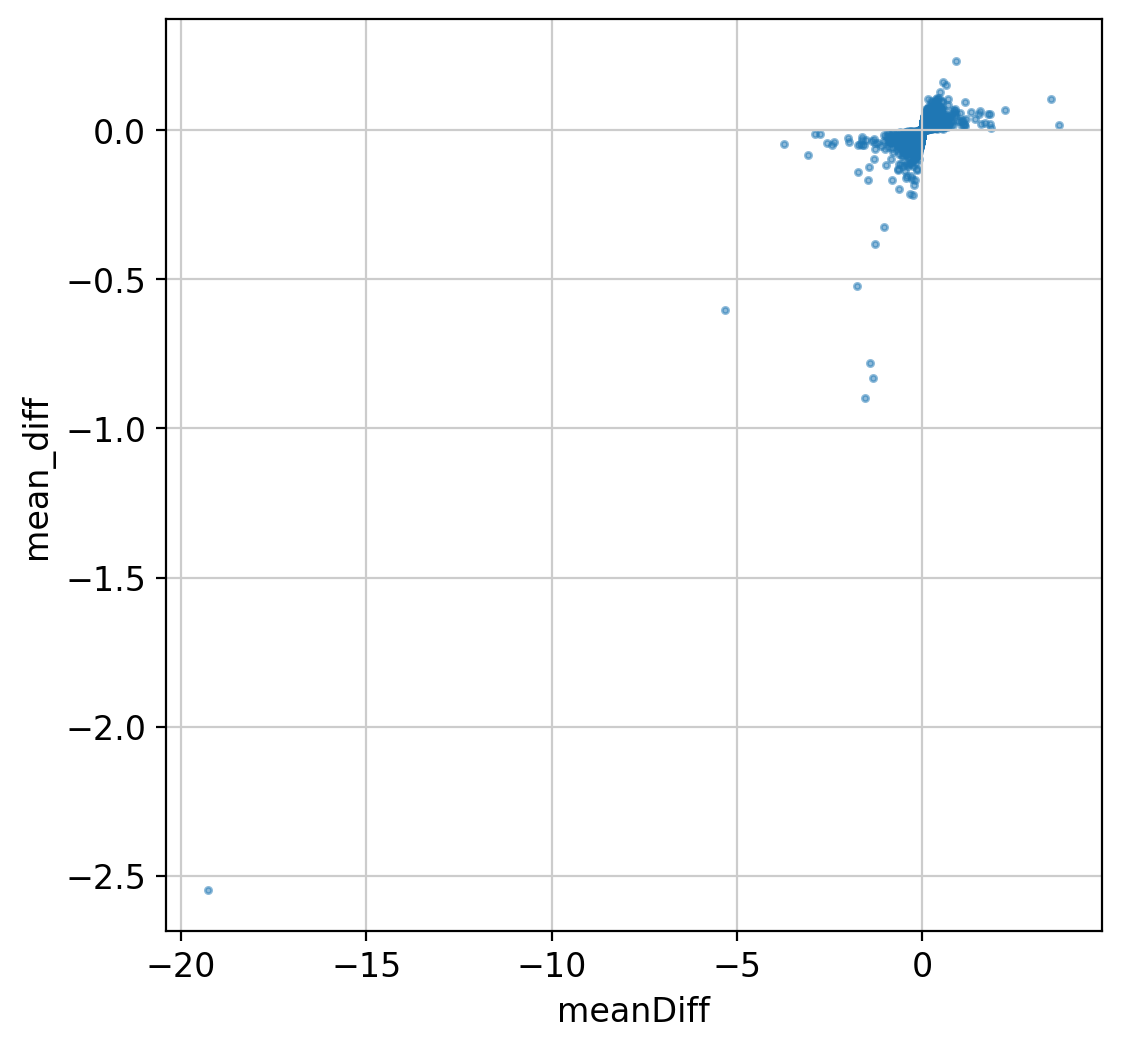

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(m["meanDiff"], m["mean_diff"], s=5, alpha=0.5)
plt.xlabel("meanDiff")
plt.ylabel("mean_diff")
plt.show()


In [ ]:
plot(m[])